# Standardize Manual S&P Mining Export

This notebook converts the manually exported S&P Global mining `.xls` file into a DuckDB database with a small relational schema that can also be populated by a richer future scrape.

The design keeps three layers:

- `properties`: one standardized row per mine/property.
- `property_texts`: verbatim long-form text fields, so no information is lost.
- `property_work_history_events`: parsed dated snippets extracted from `full_work_history_raw` when possible.

That split makes the messy last column usable in two ways at once: the raw text remains available for audit or re-parsing, while a derived event table supports downstream analysis and interchangeability with a fuller relational scrape.

## Dependencies

This notebook expects:

- `pandas`
- `duckdb`
- `python-calamine` or `xlrd` for legacy `.xls` reading
- `openai` for the LLM enrichment step

For the OpenAI enrichment cells, you also need an `OPENAI_API_KEY` environment variable in the notebook session.


In [ ]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path

import duckdb
import pandas as pd
import geopandas as gpd
from openai import OpenAI

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)


In [ ]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    for candidate in [PROJECT_ROOT.parent, PROJECT_ROOT.parent.parent, PROJECT_ROOT.parent.parent.parent]:
        if (candidate / "data_nobackup").exists():
            PROJECT_ROOT = candidate
            break

SOURCE_PATH = PROJECT_ROOT / "data_nobackup/snf_mining/raw/SPGlobal_Export_3-31-2026_d895a56a-e8e3-4698-a5c7-b2931645b812.xls"
OUTPUT_DIR = PROJECT_ROOT / "data_nobackup/snf_mining/processed/stage_0" / "manual_xls"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DB_PATH = OUTPUT_DIR / "snf_mining_manual_export.duckdb"

SOURCE_PATH, DB_PATH

In [ ]:
conn = duckdb.connect(DB_PATH)
conn.sql("LOAD spatial;")

In [ ]:
def make_gdf(df):
    return gpd.GeoDataFrame(
        df, 
        geometry = gpd.GeoSeries.from_wkt(df["geometry"]),
        crs=4326
    )

properties = make_gdf(conn.sql("""
    SELECT * FROM (SELECT
        property_id,
        primary_commodity,
        COALESCE(actual_start_up_year, llm_opening_year) AS opening_year,
        COALESCE(actual_closure_year, llm_closing_year) AS closing_year,
        ST_AsWKT(ST_POINT(longitude, latitude)) AS geometry
    FROM properties
    LEFT JOIN (
        SELECT property_id, llm_opening_year, llm_closing_year
        FROM property_llm_years
        WHERE llm_opening_year IS NOT NULL OR llm_closing_year IS NOT NULL
    ) AS b
    USING (property_id))
    WHERE (((opening_year IS NOT NULL AND closing_year IS NULL) OR closing_year >= 1992) AND (geometry IS NOT NULL))
    """).df())

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from matplotlib.patches import Wedge, Patch
from matplotlib.lines import Line2D

# ----------------------------
# 1. Commodity colors
# ----------------------------
COLOR = {
    'Gold': '#d4af37',
    'Copper': '#b87333',
    'Coal': '#4d4d4d',
    'Diamonds': '#76c7ff',
    'Vanadium': '#6a5acd',
    'Iron Ore': '#a34b2a',
    'Tin': '#91a3b0',
    'Phosphate': '#6b8e23',
    'U3O8': '#9acd32',
    'Nickel': '#8f9779',
    'Silver': '#c0c0c0',
    'Potash': '#ff7f50',
    'Bauxite': '#cd5c5c',
    'Zinc': '#7f8c8d',
    'Lead': '#5d6d7e',
    'Chromite': '#36454f',
    'Graphite': '#2f4f4f',
    'Lithium': '#ff69b4',
    'Manganese': '#8b5a2b',
    'Molybdenum': '#4682b4',
    'Lanthanides': '#20b2aa',
    'Platinum': '#e5e4e2',
    'Tantalum': '#708090',
    'Tungsten': '#556b2f',
    'Antimony': '#8b7d6b',
    'Ilmenite': '#696969',
    'Cobalt': '#0047ab',
    'Niobium': '#4169e1',
    'Zircon': '#40e0d0',
    'Palladium': '#bfc1c2',
    'Heavy Mineral Sands': '#c2b280',
    'Rutile': '#f4a460',
    'Titanium': '#b0c4de',
    'Ferronickel': '#3b6f8e'
}

# ----------------------------
# 2. Cluster geographically
# ----------------------------
def build_mine_clusters(
    gdf,
    commodity_col="commodity",
    eps_km=100,
    min_samples=1,
    projected_crs="ESRI:54009",   # World Mollweide, meter-based
):
    """
    Cluster mines by geographic proximity using DBSCAN.

    Parameters
    ----------
    gdf : GeoDataFrame in EPSG:4326 or similar
    commodity_col : str
    eps_km : float
        Max distance in km between mines in same cluster
    min_samples : int
    projected_crs : str
        CRS with meter units for clustering

    Returns
    -------
    clustered_gdf : GeoDataFrame
        Original mines with cluster_id
    cluster_summary : DataFrame
        One row per cluster with centroid and commodity counts
    """
    gdf = gdf.copy()

    # project to meters for clustering
    gdf_proj = gdf.to_crs(projected_crs)

    coords = np.column_stack([gdf_proj.geometry.x, gdf_proj.geometry.y])

    db = DBSCAN(eps=eps_km * 1000, min_samples=min_samples)
    gdf["cluster_id"] = db.fit_predict(coords)

    # cluster centroids in projected CRS
    gdf_proj["cluster_id"] = gdf["cluster_id"].values
    centroids_proj = gdf_proj.groupby("cluster_id").geometry.apply(
        lambda s: s.union_all().centroid
    )

    centroids = gpd.GeoSeries(centroids_proj, crs=projected_crs).to_crs(gdf.crs)

    # commodity counts per cluster
    counts = (
        gdf.groupby(["cluster_id", commodity_col])
        .size()
        .unstack(fill_value=0)
    )

    summary = counts.copy()
    summary["n_mines"] = summary.sum(axis=1)
    summary["geometry"] = centroids
    summary = summary.reset_index()

    cluster_summary = gpd.GeoDataFrame(summary, geometry="geometry", crs=gdf.crs)
    return gdf, cluster_summary

# ----------------------------
# 3. Pie drawing helper
# ----------------------------
def draw_pie(ax, x, y, shares, colors, radius, edgecolor="white", linewidth=0.4, zorder=5):
    """
    Draw a pie chart centered at (x, y) in data coordinates.
    """
    start = 0.0
    for frac, color in zip(shares, colors):
        if frac <= 0:
            continue
        end = start + frac * 360.0
        wedge = Wedge(
            center=(x, y),
            r=radius,
            theta1=start,
            theta2=end,
            facecolor=color,
            edgecolor=edgecolor,
            linewidth=linewidth,
            zorder=zorder,
        )
        ax.add_patch(wedge)
        start = end

# ----------------------------
# 4. Scale radius by cluster size
# ----------------------------
def radius_from_count(n, n_min, n_max, r_min, r_max, scale=1.0):
    """
    Area-like scaling using sqrt so radius doesn't explode.
    """
    if n_max == n_min:
        return (r_min + r_max) / 2
    t = (n - n_min) / (n_max - n_min)
    return scale * (r_min + (r_max - r_min) * np.sqrt(t))

# ----------------------------
# 5. Plot clustered pies
# ----------------------------
def plot_cluster_pies(
    ax,
    cluster_gdf,
    commodity_order=None,
    color_map=None,
    r_min=0.5,
    r_max=3.0,
    scale=1.0,
):
    """
    Plot one pie per cluster.

    Parameters
    ----------
    ax : matplotlib axis
    cluster_gdf : GeoDataFrame from build_mine_clusters()
    commodity_order : list[str] or None
    color_map : dict
    r_min, r_max : float
        Pie radii in axis data units (degrees if EPSG:4326)
    size_in_data_units : bool
        True works okay for world maps in lon/lat, but projected plotting is better.
    """
    color_map = color_map or COLOR

    commodity_cols = [
        c for c in cluster_gdf.columns
        if c not in {"cluster_id", "n_mines", "geometry"}
    ]

    if commodity_order is None:
        commodity_order = [c for c in commodity_cols if c in color_map]
    else:
        commodity_order = [c for c in commodity_order if c in commodity_cols]

    n_min = cluster_gdf["n_mines"].min()
    n_max = cluster_gdf["n_mines"].max()

    for _, row in cluster_gdf.iterrows():
        vals = np.array([row.get(c, 0) for c in commodity_order], dtype=float)
        total = vals.sum()
        if total == 0:
            continue

        shares = vals / total
        colors = [color_map.get(c, "#999999") for c in commodity_order]
        x, y = row.geometry.x, row.geometry.y
        radius = radius_from_count(row["n_mines"], n_min, n_max, r_min, r_max, scale=scale)

        draw_pie(ax, x, y, shares, colors, radius=radius)

In [ ]:
world = gpd.read_file("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/misc/processed/stage_1/gadm/gadm_levelADM_0_simplified.gpkg")
#
plot_crs = "ESRI:54009"
#
world_proj = world.to_crs(plot_crs)
properties_proj = properties.to_crs(plot_crs)

_, cluster_summary_proj = build_mine_clusters(
    properties_proj,
    commodity_col="primary_commodity",
    eps_km=150,
    min_samples=5
)

In [ ]:
commodity_cols = [c for c in COLOR if c in cluster_summary_proj.columns and cluster_summary_proj[c].sum() > 0]

fig, ax = plt.subplots(figsize=(14, 8))

world_proj.boundary.plot(ax=ax, color="lightgray", linewidth=0.5)

plot_cluster_pies(
    ax,
    cluster_summary_proj,
    color_map=COLOR,
    r_min=100000,
    r_max=500000,
    scale=2
)

# crop to data
xmin, ymin, xmax, ymax = cluster_summary_proj.total_bounds
ax.set_ylim(ymin - 1_000_000, ymax + 1_500_000)

ax.set_aspect("equal")
ax.set_axis_off()

# reserve a compact band below the map
fig.subplots_adjust(bottom=0.30)

# commodity legend
commodity_handles = [
    Patch(facecolor=COLOR[c], edgecolor="white", label=c)
    for c in commodity_cols
]

leg1 = fig.legend(
    handles=commodity_handles,
    title="Commodity",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.11),
    ncol=6,
    frameon=True,
    fontsize=9,
    title_fontsize=11,
)

# size legend
size_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=6,
           markerfacecolor='none', markeredgecolor='black', label='10'),
    Line2D([0], [0], marker='o', linestyle='', markersize=10,
           markerfacecolor='none', markeredgecolor='black', label='50'),
    Line2D([0], [0], marker='o', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='black', label='200'),
]

leg2 = fig.legend(
    handles=size_handles,
    title="Number of mines",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=3,
    frameon=True,
    fontsize=9,
    title_fontsize=11,
)

plt.show()

---

In [ ]:
test = conn.sql("SELECT ST_AsWKT(ST_BUFFER(ST_POINT(longitude, latitude), 1)) FROM properties LIMIT 1").df()

In [ ]:
test

In [ ]:
conn.close()

In [ ]:
gpd.GeoSeries.from_wkt(test.iloc[:, 0]).plot()

In [ ]:
# Simplify ADM2
conn = duckdb.connect()
conn.sql("LOAD spatial;")

In [ ]:
conn.sql("SELECT layers[1] FROM ST_Read_Meta('C:\\Users\\schulz0022\\Documents\\gnt\\data\\misc\\gadm\\raw\\gadm_410-gpkg\\gadm_410.gpkg')").fetchone()

In [ ]:
conn.sql("SELECT * FROM ST_READ('C:\\Users\\schulz0022\\Documents\\gnt\\data\\misc\\gadm\\raw\\gadm_410-gpkg\\gadm_410.gpkg') LIMIT 10")

In [ ]:
, layer=''

In [ ]:
adm2 = conn.sql("SELECT id, name, ST_SimplifyPreserveTopology(geometry, 0.01) AS geometry FROM adm2").df()
conn.close()

---

In [28]:
import numpy as np
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt

In [10]:
mining = xr.open_zarr("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/snl_mining/processed/stage_2/snl_mining_timeseries_reprojected.zarr", consolidated=False)
mining = mining.rio.write_crs(4326)

In [21]:
johannesburg = mining.rio.clip_box(*[27.5, -26.5, 28.5, -26.0]).compute()

In [22]:
johannesburg

<xarray.Dataset> Size: 19MB
Dimensions:          (longitude: 241, latitude: 121, time: 33, band: 1)
Coordinates:
  * longitude        (longitude) float64 2kB 27.5 27.5 27.51 ... 28.49 28.5 28.5
  * latitude         (latitude) float64 968B -26.0 -26.0 -26.01 ... -26.5 -26.5
  * time             (time) datetime64[ns] 264B 1992-12-31 ... 2024-12-31
  * band             (band) int64 8B 1
    spatial_ref      int64 8B 0
Data variables:
    mine_count_10km  (time, band, latitude, longitude) float32 4MB nan ... nan
    mine_count_20km  (time, band, latitude, longitude) float32 4MB nan ... 1.0
    mine_count_adm1  (time, band, latitude, longitude) float32 4MB 22.0 ... 24.0
    mine_count_50km  (time, band, latitude, longitude) float32 4MB 11.0 ... 11.0
    mine_count_adm2  (time, band, latitude, longitude) float32 4MB 10.0 ... 4.0
Attributes:
    source_duckdb_path:         /scicore/home/meiera/schulz0022/projects/grow...
    prepared_duckdb_path:       /scicore/home/meiera/schulz0022/projects/grow...
    metric_crs:                 ESRI:54009
    radius_semantics:           count of active mine buffers covering pixel c...
    admin_semantics:            count of active mines in containing ADM polygon
    duckdb_tile_fetch_pattern:  WHERE ST_Intersects(geometry_raster, <constan...

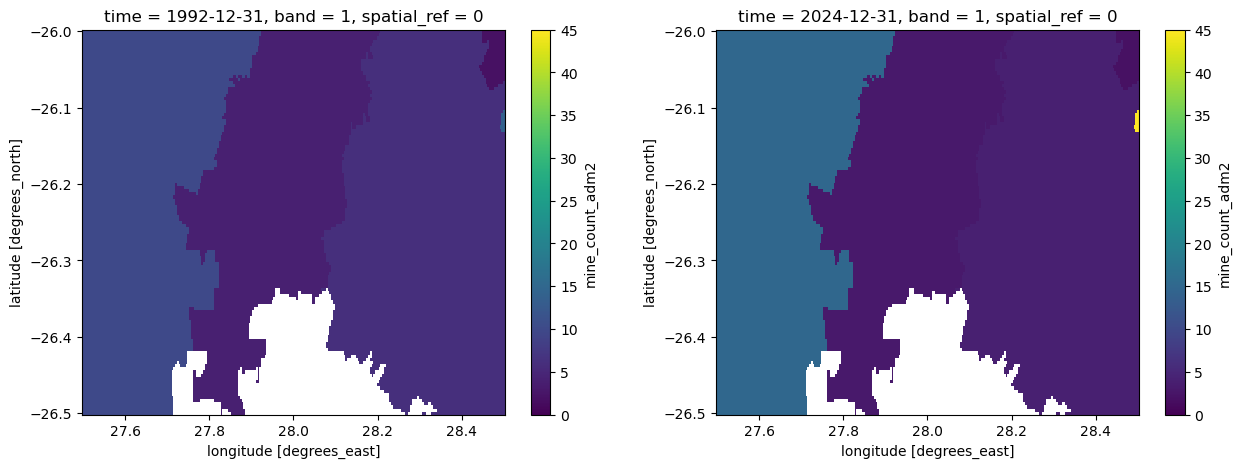

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
vmax = johannesburg.mine_count_adm2.max().values

johannesburg.isel(time=0).squeeze().mine_count_adm2.plot.imshow(ax=ax[0], vmin=0, vmax=vmax)
johannesburg.isel(time=-1).squeeze().mine_count_adm2.plot.imshow(ax=ax[1], vmin=0, vmax=vmax)

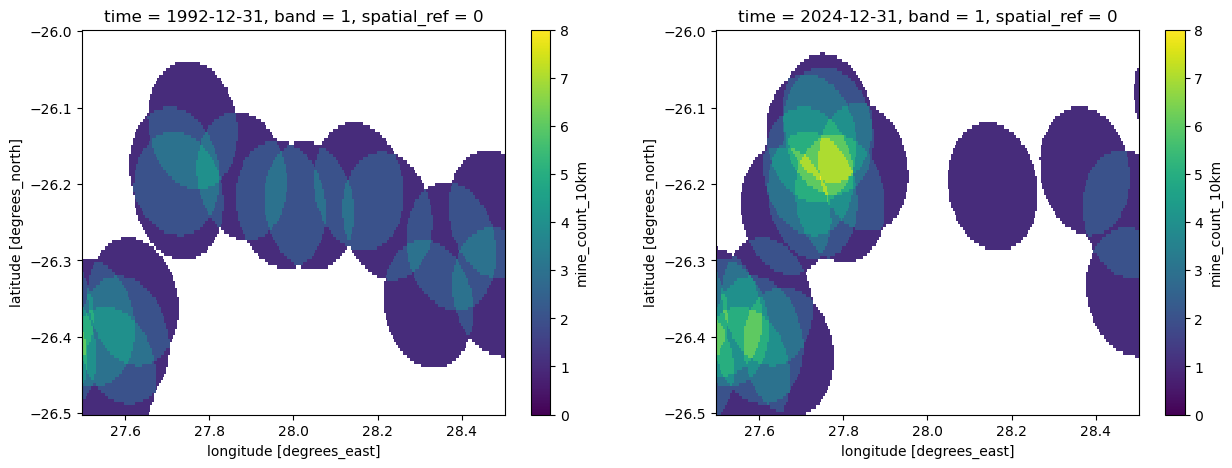

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
vmax = johannesburg.mine_count_10km.max().values

johannesburg.isel(time=0).squeeze().mine_count_10km.plot.imshow(ax=ax[0], vmin=0, vmax=vmax)
johannesburg.isel(time=-1).squeeze().mine_count_10km.plot.imshow(ax=ax[1], vmin=0, vmax=vmax)

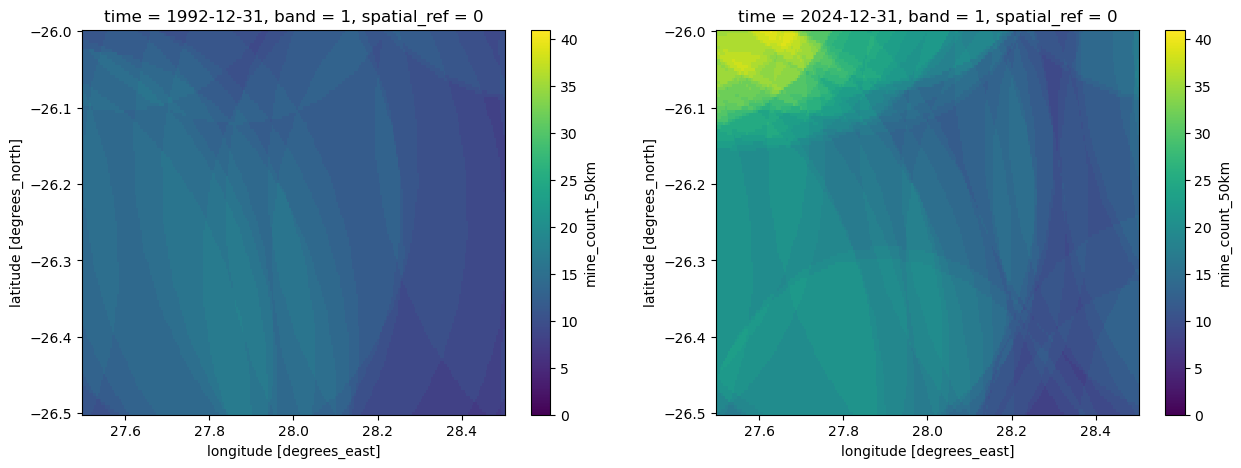

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
vmax = johannesburg.mine_count_50km.max().values

johannesburg.isel(time=0).squeeze().mine_count_50km.plot.imshow(ax=ax[0], vmin=0, vmax=vmax)
johannesburg.isel(time=-1).squeeze().mine_count_50km.plot.imshow(ax=ax[1], vmin=0, vmax=vmax)